# 08 — Treasury Yield Features

Test whether adding macro yield-curve context improves the 3-month XGBoost model.

**Hypothesis:** Treasury yield data encodes the interest-rate regime (normal vs. inverted curve,
rising vs. falling rates) that is *not* captured by individual stock technicals.
Each feature is date-level (same value for all stocks on a given trading day).

**Baseline (from notebook 06/07):**
| Metric | Value |
|--------|-------|
| Weighted F1 | 0.2612 (nb06 production) / 0.2645 (nb07 re-run) |
| MAE | 1.3651 / 1.3515 |
| Features | 22 (19 tech + 3 GDELT sentiment) |

**This notebook adds 3 yield features:**
| Feature | Description |
|---------|-------------|
| `yield_spread` | 10y − 3m yield (positive = normal curve, negative = inverted) |
| `yield_10y_mom_20d` | 20-day change in 10y yield (rising vs. falling rates) |
| `yield_spread_mom_20d` | 20-day change in spread (steepening vs. flattening momentum) |

No Optuna — default XGBoost params only. Default params beat all tuned variants in nb07.

In [1]:
import os
import json
import re
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yfinance as yf
from sklearn.metrics import accuracy_score, classification_report, f1_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
print("Imports OK")

Imports OK


## 1. Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
CACHE_DIR   = os.path.join(".", "data")
MODEL_DIR   = os.path.join("..", "src", "ml", "app", "models")
METADATA_PATH  = os.path.join(MODEL_DIR, "training_metadata.json")
OHLCV_CACHE    = os.path.join(CACHE_DIR, "sp500_ohlcv_5y.parquet")
GDELT_CACHE    = os.path.join(CACHE_DIR, "gdelt_sentiment_5y.parquet")
YIELD_CACHE    = os.path.join(CACHE_DIR, "treasury_yields_5y.parquet")

# ── Constants ───────────────────────────────────────────────────────────────
SIGNAL_LABELS   = ["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"]
THRESHOLDS_3M   = (-10, -3, 3, 12)
HORIZON_DAYS_3M = 63
SPLIT_DATE      = pd.Timestamp("2025-09-01")

# ── Feature lists ──────────────────────────────────────────────────────────
TECH_FEATURES = [
    "Price_SMA50_Ratio", "Price_SMA200_Ratio", "Price_EMA20_Ratio",
    "MACD_Norm", "MACD_Signal_Norm", "MACD_Hist_Norm",
    "RSI", "Stoch_K", "Stoch_D", "ROC",
    "BB_Position", "BB_Width", "ATR_Pct",
    "OBV_Norm", "Vol_SMA_Ratio",
    "Dist_52w_High", "Dist_52w_Low", "Return_1m", "Return_3m",
]
SENTIMENT_FEATURES = ["sentiment_avg_20d", "sentiment_volume_20d", "sentiment_momentum"]
BASELINE_FEATURES  = TECH_FEATURES + SENTIMENT_FEATURES   # 22 features

YIELD_FEATURES = ["yield_spread", "yield_10y_mom_20d", "yield_spread_mom_20d"]
EXTENDED_FEATURES = BASELINE_FEATURES + YIELD_FEATURES    # 25 features

print(f"Baseline : {len(BASELINE_FEATURES)} features ({len(TECH_FEATURES)} tech + {len(SENTIMENT_FEATURES)} sent)")
print(f"Extended : {len(EXTENDED_FEATURES)} features (+{len(YIELD_FEATURES)} yield)")
print(f"Split    : {SPLIT_DATE.date()}")

Baseline : 22 features (19 tech + 3 sent)
Extended : 25 features (+3 yield)
Split    : 2025-09-01


## 2. Helper Functions

In [3]:
def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    sma_50  = df["Close"].rolling(50).mean()
    sma_200 = df["Close"].rolling(200).mean()
    ema_20  = df["Close"].ewm(span=20, adjust=False).mean()
    df["Price_SMA50_Ratio"]  = df["Close"] / sma_50
    df["Price_SMA200_Ratio"] = df["Close"] / sma_200
    df["Price_EMA20_Ratio"]  = df["Close"] / ema_20

    ema_12  = df["Close"].ewm(span=12, adjust=False).mean()
    ema_26  = df["Close"].ewm(span=26, adjust=False).mean()
    macd_raw = ema_12 - ema_26
    macd_sig = macd_raw.ewm(span=9, adjust=False).mean()
    df["MACD_Norm"]        = macd_raw / df["Close"] * 100
    df["MACD_Signal_Norm"] = macd_sig / df["Close"] * 100
    df["MACD_Hist_Norm"]   = df["MACD_Norm"] - df["MACD_Signal_Norm"]

    delta    = df["Close"].diff()
    gain     = delta.where(delta > 0, 0.0)
    loss     = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    df["RSI"] = 100 - (100 / (1 + avg_gain / avg_loss))

    low_14  = df["Low"].rolling(14).min()
    high_14 = df["High"].rolling(14).max()
    df["Stoch_K"] = 100 * (df["Close"] - low_14) / (high_14 - low_14)
    df["Stoch_D"] = df["Stoch_K"].rolling(3).mean()
    df["ROC"]     = df["Close"].pct_change(21) * 100

    bb_sma   = df["Close"].rolling(20).mean()
    bb_std   = df["Close"].rolling(20).std()
    bb_upper = bb_sma + 2 * bb_std
    bb_lower = bb_sma - 2 * bb_std
    df["BB_Position"] = (df["Close"] - bb_lower) / (bb_upper - bb_lower)
    df["BB_Width"]    = (bb_upper - bb_lower) / bb_sma

    tr = pd.concat([
        df["High"] - df["Low"],
        (df["High"] - df["Close"].shift(1)).abs(),
        (df["Low"]  - df["Close"].shift(1)).abs(),
    ], axis=1).max(axis=1)
    df["ATR_Pct"] = tr.rolling(14).mean() / df["Close"] * 100

    obv           = (np.sign(df["Close"].diff()) * df["Volume"]).cumsum()
    df["OBV_Norm"]     = obv.diff(21) / df["Volume"].rolling(21).mean()
    df["Vol_SMA_Ratio"] = df["Volume"] / df["Volume"].rolling(20).mean()

    df["Dist_52w_High"] = (df["Close"] - df["High"].rolling(252).max()) / df["High"].rolling(252).max() * 100
    df["Dist_52w_Low"]  = (df["Close"] - df["Low"].rolling(252).min())  / df["Low"].rolling(252).min()  * 100
    df["Return_1m"]     = df["Close"].pct_change(21) * 100
    df["Return_3m"]     = df["Close"].pct_change(63) * 100

    return df


def compute_future_returns(close, horizon_days):
    return (close.shift(-horizon_days) / close - 1) * 100


def assign_signal(returns, thresholds):
    ss, s, b, sb = thresholds
    conditions = [
        returns < ss,
        (returns >= ss) & (returns < s),
        (returns >= s)  & (returns < b),
        (returns >= b)  & (returns < sb),
        returns >= sb,
    ]
    return pd.Series(
        np.select(conditions, SIGNAL_LABELS, default=""),
        index=returns.index,
    ).replace("", np.nan)


def clean_company_name(name):
    name = name.lower().strip().replace(",", " ").replace(".", " ")
    name = re.sub(r"\s+", " ", name).strip()
    name = re.sub(r"^the ", "", name)
    name = re.sub(r"\s*&\s*co\s*$", "", name)
    name = re.sub(
        r"\s+(inc|corp|co|ltd|llc|plc|lp|nv|sa|corporation|incorporated|"
        r"company|companies|holdings|group|enterprises?|international)\s*$",
        "", name)
    return name.strip()


def compute_sentiment_features(scored_df, processed):
    all_features = []
    tickers = scored_df["ticker"].unique()
    for i, ticker in enumerate(tickers, 1):
        if ticker not in processed:
            continue
        daily = scored_df[scored_df["ticker"] == ticker].groupby("date").agg(
            daily_sentiment=("sentiment", "mean"),
            daily_count=("sentiment", "count"),
        )
        trading_dates = processed[ticker].index
        daily_aligned = daily.reindex(trading_dates)
        daily_aligned["daily_sentiment"] = daily_aligned["daily_sentiment"].ffill()
        daily_aligned["daily_count"]     = daily_aligned["daily_count"].fillna(0)

        sent_avg_20 = daily_aligned["daily_sentiment"].rolling(20, min_periods=5).mean()
        sent_avg_60 = daily_aligned["daily_sentiment"].rolling(60, min_periods=10).mean()
        sent_vol_20 = daily_aligned["daily_count"].rolling(20, min_periods=1).sum()

        all_features.append(pd.DataFrame({
            "ticker":              ticker,
            "date":                trading_dates,
            "sentiment_avg_20d":   sent_avg_20.values,
            "sentiment_volume_20d": sent_vol_20.values,
            "sentiment_momentum":  (sent_avg_20 - sent_avg_60).values,
        }))
        if i % 100 == 0:
            print(f"  [{i}/{len(tickers)}] tickers")
    return pd.concat(all_features, ignore_index=True)


def eval_model(y_true, y_pred, label="Model"):
    f1  = f1_score(y_true, y_pred, average="weighted")
    acc = accuracy_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{label}: F1={f1:.4f}  Acc={acc:.4f}  MAE={mae:.4f}")
    return {"f1": f1, "acc": acc, "mae": mae}


def bootstrap_ci(y_true, y_pred, n=1000, seed=42):
    rng = np.random.default_rng(seed)
    scores = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = rng.integers(0, n_samples, n_samples)
        scores.append(f1_score(y_true[idx], y_pred[idx], average="weighted"))
    return np.percentile(scores, [2.5, 97.5])


print("Helper functions loaded.")

Helper functions loaded.


## 3. Load Data

Reuses the exact same parquet caches as notebooks 06 & 07 — no re-downloading.

In [4]:
# ── OHLCV ───────────────────────────────────────────────────────────────────
print("Loading OHLCV data...")
ohlcv_all = pd.read_parquet(OHLCV_CACHE)
all_data = {}
for ticker in ohlcv_all["Ticker"].unique():
    df = ohlcv_all[ohlcv_all["Ticker"] == ticker].drop(columns=["Ticker"])
    df.index = pd.to_datetime(df.index)
    all_data[ticker] = df
print(f"Loaded {len(all_data)} tickers")

# ── Technical features ───────────────────────────────────────────────────────
print("Computing technical features...")
processed = {}
for ticker, df in all_data.items():
    feat = compute_features(df)
    feat = feat.dropna(subset=TECH_FEATURES)
    if len(feat) > 0:
        processed[ticker] = feat
print(f"Features computed for {len(processed)} tickers")

Loading OHLCV data...
Loaded 499 tickers
Computing technical features...
Features computed for 499 tickers


In [5]:
# ── S&P 500 table + GDELT sentiment ──────────────────────────────────────────
with open(METADATA_PATH) as f:
    metadata = json.load(f)
tickers = metadata["training_tickers"]

print("Fetching S&P 500 table from Wikipedia...")
resp = requests.get(
    "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
    headers={"User-Agent": "StockPredictor/1.0 (thesis)"},
    timeout=15,
)
resp.raise_for_status()
sp500_table = pd.read_html(resp.text)[0]
print(f"Got {len(sp500_table)} companies")

ticker_to_company = {}
for t in tickers:
    row = sp500_table[sp500_table["Symbol"] == t]
    if row.empty:
        row = sp500_table[sp500_table["Symbol"] == t.replace("-", ".")]
    if not row.empty:
        ticker_to_company[t] = clean_company_name(row.iloc[0]["Security"])

company_to_tickers = {}
for t, company in ticker_to_company.items():
    company_to_tickers.setdefault(company, []).append(t)

print("Loading GDELT sentiment data...")
gdelt_df = pd.read_parquet(GDELT_CACHE)
gdelt_df["date"] = pd.to_datetime(gdelt_df["article_date"], format="%Y%m%d")

mapping_rows = []
for company, ticker_list in company_to_tickers.items():
    for t in ticker_list:
        mapping_rows.append({"matched_org": company, "ticker": t})
mapping_df = pd.DataFrame(mapping_rows)

scored_df = gdelt_df.merge(mapping_df, on="matched_org", how="inner")
scored_df["sentiment"] = np.clip(scored_df["tone"] / 10, -1, 1)
scored_df = scored_df[["ticker", "date", "sentiment"]].copy()
print(f"Scored: {len(scored_df):,} records for {scored_df['ticker'].nunique()} tickers")

print("\nComputing rolling sentiment features (this takes a few minutes)...")
sentiment_features = compute_sentiment_features(scored_df, processed)
print(f"Sentiment: {len(sentiment_features):,} rows for {sentiment_features['ticker'].nunique()} tickers")

Fetching S&P 500 table from Wikipedia...
Got 503 companies
Loading GDELT sentiment data...
Scored: 66,016,919 records for 427 tickers

Computing rolling sentiment features (this takes a few minutes)...
  [100/427] tickers
  [200/427] tickers
  [300/427] tickers
  [400/427] tickers
Sentiment: 426,780 rows for 427 tickers


In [6]:
# ── Build 3m labeled dataset ─────────────────────────────────────────────────
print("Building 3m labeled dataset...")
datasets = []
for ticker, df in processed.items():
    future_ret = compute_future_returns(df["Close"], HORIZON_DAYS_3M)
    signals    = assign_signal(future_ret, THRESHOLDS_3M)
    subset     = df[TECH_FEATURES].copy()
    subset["Signal"] = signals
    subset["Ticker"] = ticker
    subset = subset.dropna(subset=TECH_FEATURES + ["Signal"])
    if len(subset) > 0:
        datasets.append(subset)

df_3m = pd.concat(datasets)

# Merge sentiment
sentiment_features["date"] = pd.to_datetime(sentiment_features["date"])
df_3m = df_3m.reset_index()
date_col = "Date" if "Date" in df_3m.columns else df_3m.columns[0]
df_3m = df_3m.rename(columns={date_col: "date"})
df_3m["date"] = pd.to_datetime(df_3m["date"])

df_3m = df_3m.merge(
    sentiment_features[["ticker", "date"] + SENTIMENT_FEATURES],
    left_on=["Ticker", "date"],
    right_on=["ticker", "date"],
    how="left",
).drop(columns=["ticker"], errors="ignore")

df_3m = df_3m.set_index("date").sort_index()

print(f"Dataset: {len(df_3m):,} samples, {df_3m['Ticker'].nunique()} tickers")
print(f"Date range: {df_3m.index.min().date()} → {df_3m.index.max().date()}")

sentiment_coverage = df_3m["sentiment_avg_20d"].notna().mean() * 100
print(f"Sentiment coverage: {sentiment_coverage:.1f}%")

print("\nClass distribution:")
counts = df_3m["Signal"].value_counts().reindex(SIGNAL_LABELS)
for label, count in zip(SIGNAL_LABELS, counts):
    print(f"  {label:>12}: {int(count):6,}  ({count/len(df_3m)*100:5.1f}%)")

Building 3m labeled dataset...
Dataset: 467,631 samples, 499 tickers
Date range: 2022-03-23 → 2025-12-19
Sentiment coverage: 83.3%

Class distribution:
   Strong Sell: 77,271  ( 16.5%)
          Sell: 77,464  ( 16.6%)
          Hold: 82,560  ( 17.7%)
           Buy: 112,164  ( 24.0%)
    Strong Buy: 118,172  ( 25.3%)


## 4. Treasury Yield Features

Downloads 10-year (`^TNX`) and 3-month (`^IRX`) Treasury yields via yfinance and computes
three macro regime features.

| Feature | Formula | Economic meaning |
|---------|---------|-----------------|
| `yield_spread` | 10y − 3m | Slope of yield curve; negative = inverted (recession signal) |
| `yield_10y_mom_20d` | Δ10y over 20 days | Rate direction; rising = tightening, falling = easing |
| `yield_spread_mom_20d` | Δspread over 20 days | Curve steepening vs. flattening momentum |

All three are date-level (identical across all tickers on a given day).

In [7]:
if os.path.exists(YIELD_CACHE):
    yields_raw = pd.read_parquet(YIELD_CACHE)
    print("Loaded Treasury yields from cache")
else:
    print("Downloading Treasury yield data via yfinance...")
    tnx = yf.download("^TNX", period="5y", auto_adjust=True, progress=False)
    irx = yf.download("^IRX", period="5y", auto_adjust=True, progress=False)

    if isinstance(tnx.columns, pd.MultiIndex):
        tnx.columns = tnx.columns.get_level_values(0)
    if isinstance(irx.columns, pd.MultiIndex):
        irx.columns = irx.columns.get_level_values(0)

    yields_raw = pd.DataFrame({
        "yield_10y": tnx["Close"],
        "yield_3m":  irx["Close"],
    })
    yields_raw.index = pd.to_datetime(yields_raw.index)
    yields_raw.to_parquet(YIELD_CACHE)
    print(f"Saved yield cache: {YIELD_CACHE}")

yields_raw = yields_raw.ffill()   # fill any non-trading-day gaps
print(f"Yield data: {len(yields_raw)} rows  ({yields_raw.index.min().date()} → {yields_raw.index.max().date()})")
print(f"  10y range: {yields_raw['yield_10y'].min():.2f}% – {yields_raw['yield_10y'].max():.2f}%")
print(f"  3m range : {yields_raw['yield_3m'].min():.2f}% – {yields_raw['yield_3m'].max():.2f}%")

Saved yield cache: .\data\treasury_yields_5y.parquet
Yield data: 1256 rows  (2021-03-31 → 2026-03-31)
  10y range: 1.17% – 4.99%
  3m range : 0.00% – 5.35%


In [8]:
# ── Compute yield features ────────────────────────────────────────────────────
y10  = yields_raw["yield_10y"]
y3m  = yields_raw["yield_3m"]

yield_features_daily = pd.DataFrame(index=yields_raw.index)
yield_features_daily["yield_spread"]        = y10 - y3m
yield_features_daily["yield_10y_mom_20d"]   = y10.diff(20)
yield_features_daily["yield_spread_mom_20d"] = yield_features_daily["yield_spread"].diff(20)

print("Yield feature stats:")
print(yield_features_daily.describe().round(3))

# Quick sanity: yield curve inversion periods
n_inverted = (yield_features_daily["yield_spread"] < 0).sum()
print(f"\nInverted curve days: {n_inverted} ({n_inverted/len(yield_features_daily)*100:.1f}% of trading days)")

Yield feature stats:
       yield_spread  yield_10y_mom_20d  yield_spread_mom_20d
count      1256.000           1236.000              1236.000
mean          0.124              0.043                -0.015
std           1.041              0.264                 0.287
min          -1.704             -0.718                -1.287
25%          -0.887             -0.134                -0.165
50%           0.169              0.027                 0.007
75%           1.166              0.217                 0.170
max           2.308              0.854                 0.754

Inverted curve days: 524 (41.7% of trading days)


In [9]:
# ── Merge into df_3m by date (left join on index) ────────────────────────────
df_3m_ext = df_3m.copy()
df_3m_ext = df_3m_ext.merge(
    yield_features_daily[YIELD_FEATURES],
    left_index=True,
    right_index=True,
    how="left",
)

# Forward-fill any residual gaps (e.g., date alignment edge cases)
for feat in YIELD_FEATURES:
    df_3m_ext[feat] = df_3m_ext[feat].ffill()

# Coverage check
yield_coverage = df_3m_ext["yield_spread"].notna().mean() * 100
print(f"Yield coverage after merge: {yield_coverage:.1f}%")
print(f"Dataset size unchanged: {len(df_3m_ext):,} rows")

# Correlation with existing features (should be low — macro orthogonal to technicals)
print("\nCorrelation of yield features vs. existing tech features (abs > 0.3):")
corr_check = df_3m_ext[BASELINE_FEATURES + YIELD_FEATURES].corr()[YIELD_FEATURES]
high_corr = corr_check[corr_check.abs().max(axis=1) > 0.3].drop(YIELD_FEATURES, errors="ignore")
if len(high_corr) == 0:
    print("  None — yield features are orthogonal to technicals (good)")
else:
    print(high_corr.round(3))

Yield coverage after merge: 100.0%
Dataset size unchanged: 467,631 rows

Correlation of yield features vs. existing tech features (abs > 0.3):
  None — yield features are orthogonal to technicals (good)


## 5. Model Comparison

Train two models with identical hyperparameters (default XGBoost, confirmed best in nb07):
- **Model A:** 22 baseline features (tech + sentiment)  
- **Model B:** 25 features (baseline + 3 yield features)

In [10]:
le = LabelEncoder()
le.fit(SIGNAL_LABELS)
n_classes = len(SIGNAL_LABELS)

# ── Split ────────────────────────────────────────────────────────────────────
train_a = df_3m[df_3m.index < SPLIT_DATE].copy()
test_a  = df_3m[df_3m.index >= SPLIT_DATE].copy()

train_b = df_3m_ext[df_3m_ext.index < SPLIT_DATE].copy()
test_b  = df_3m_ext[df_3m_ext.index >= SPLIT_DATE].copy()

y_train = le.transform(train_a["Signal"])
y_test  = le.transform(test_a["Signal"])

# Class weights (inverse frequency, computed on training labels)
class_counts = Counter(y_train)
total = len(y_train)
class_weights_dict = {cls: total / (n_classes * cnt) for cls, cnt in class_counts.items()}
sample_weights = np.array([class_weights_dict[y] for y in y_train])

print(f"Train: {len(train_a):,}  Test: {len(test_a):,}")
print(f"Class weights: {dict(zip(le.classes_, [f'{class_weights_dict[i]:.2f}' for i in range(n_classes)]))}")

Train: 428,713  Test: 38,918
Class weights: {np.str_('Buy'): '0.83', np.str_('Hold'): '1.13', np.str_('Sell'): '1.20', np.str_('Strong Buy'): '0.80', np.str_('Strong Sell'): '1.22'}


In [11]:
DEFAULT_PARAMS = dict(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective="multi:softprob", num_class=n_classes,
    eval_metric="mlogloss", random_state=42, n_jobs=-1,
)

# ── Model A: Baseline (22 features) ─────────────────────────────────────────
print("Training Model A: Baseline (22 features)...")
model_a = XGBClassifier(**DEFAULT_PARAMS)
model_a.fit(train_a[BASELINE_FEATURES], y_train, sample_weight=sample_weights)
y_pred_a = model_a.predict(test_a[BASELINE_FEATURES])
metrics_a = eval_model(y_test, y_pred_a, "Model A — Baseline (22 feat)")

# ── Model B: Baseline + Yield (25 features) ─────────────────────────────────
print("\nTraining Model B: Baseline + Yield (25 features)...")
model_b = XGBClassifier(**DEFAULT_PARAMS)
model_b.fit(train_b[EXTENDED_FEATURES], y_train, sample_weight=sample_weights)
y_pred_b = model_b.predict(test_b[EXTENDED_FEATURES])
metrics_b = eval_model(y_test, y_pred_b, "Model B — Baseline + Yield (25 feat)")

print(f"\nDelta F1 : {metrics_b['f1']  - metrics_a['f1']:+.4f}")
print(f"Delta MAE: {metrics_b['mae'] - metrics_a['mae']:+.4f}")

Training Model A: Baseline (22 features)...
Model A — Baseline (22 feat): F1=0.2645  Acc=0.2646  MAE=1.3515

Training Model B: Baseline + Yield (25 features)...
Model B — Baseline + Yield (25 feat): F1=0.2283  Acc=0.2470  MAE=1.4629

Delta F1 : -0.0362
Delta MAE: +0.1114


In [12]:
# ── Bootstrap confidence intervals ───────────────────────────────────────────
print("Computing bootstrap CIs (1000 resamples each)...")
ci_a = bootstrap_ci(y_test, y_pred_a)
ci_b = bootstrap_ci(y_test, y_pred_b)

print(f"\nModel A  F1 = {metrics_a['f1']:.4f}  95% CI: [{ci_a[0]:.4f}, {ci_a[1]:.4f}]")
print(f"Model B  F1 = {metrics_b['f1']:.4f}  95% CI: [{ci_b[0]:.4f}, {ci_b[1]:.4f}]")

overlap = ci_a[1] >= ci_b[0] and ci_b[1] >= ci_a[0]
if not overlap:
    print("\n✓ CIs do NOT overlap — improvement is statistically significant")
else:
    print("\n✗ CIs overlap — improvement is NOT statistically significant")

print("\nClassification Report — Model B:")
print(classification_report(y_test, y_pred_b, target_names=SIGNAL_LABELS, zero_division=0))

Computing bootstrap CIs (1000 resamples each)...

Model A  F1 = 0.2645  95% CI: [0.2604, 0.2688]
Model B  F1 = 0.2283  95% CI: [0.2239, 0.2327]

✓ CIs do NOT overlap — improvement is statistically significant

Classification Report — Model B:
              precision    recall  f1-score   support

 Strong Sell       0.28      0.12      0.17      8415
        Sell       0.24      0.23      0.24      6391
        Hold       0.19      0.23      0.21      6087
         Buy       0.41      0.15      0.22     11254
  Strong Buy       0.23      0.60      0.33      6771

    accuracy                           0.25     38918
   macro avg       0.27      0.27      0.23     38918
weighted avg       0.29      0.25      0.23     38918



## 6. Feature Importance — Model B

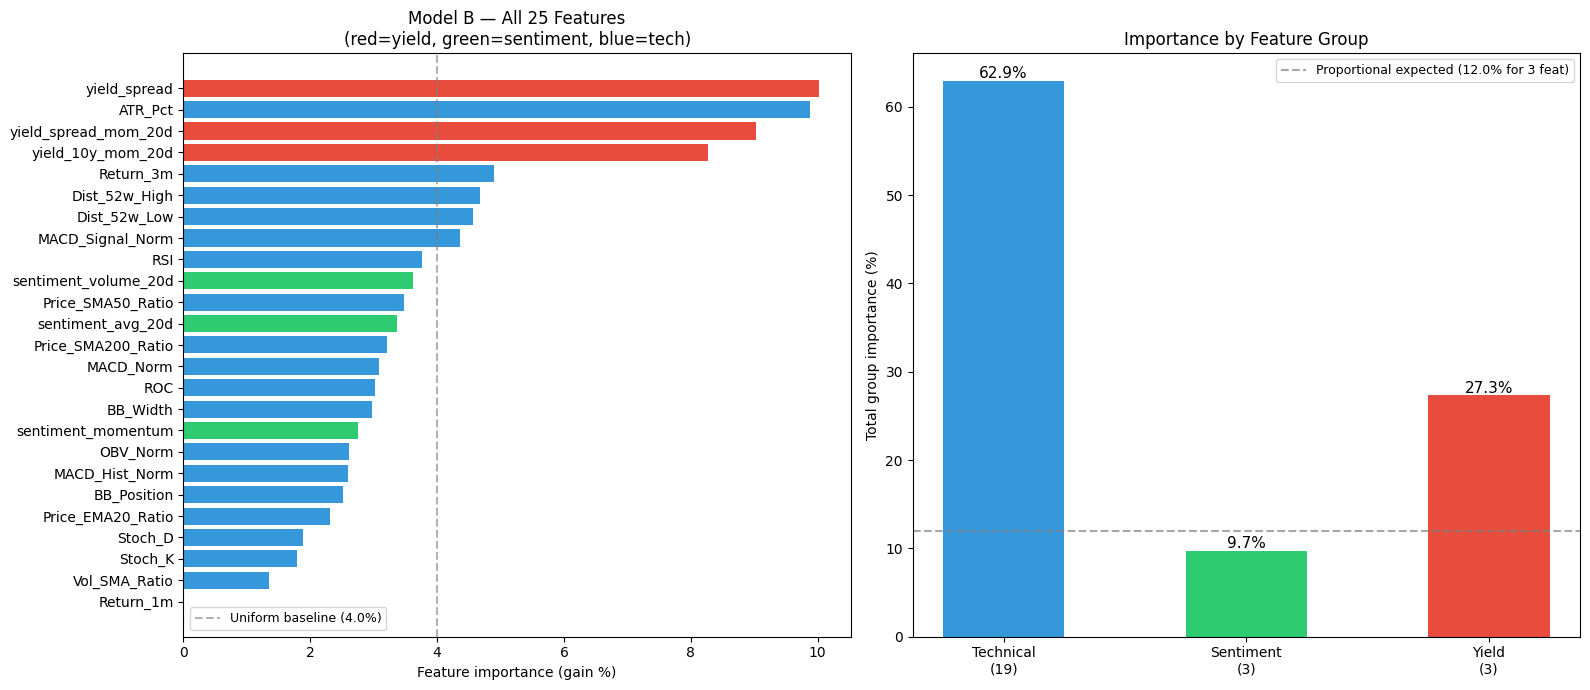


Yield features capture 27.3% of total model importance
  (expected if proportional: 12.0%)


In [13]:
importances_b = pd.Series(model_b.feature_importances_, index=EXTENDED_FEATURES)
importances_b = importances_b.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Full importance chart ────────────────────────────────────────────────────
colors = ["#e74c3c" if f in YIELD_FEATURES
          else "#2ecc71" if f in SENTIMENT_FEATURES
          else "#3498db"
          for f in importances_b.index]
axes[0].barh(importances_b.index, importances_b.values * 100, color=colors)
axes[0].set_xlabel("Feature importance (gain %)")
axes[0].set_title("Model B — All 25 Features\n(red=yield, green=sentiment, blue=tech)")
axes[0].axvline(x=100/len(EXTENDED_FEATURES), color="gray", linestyle="--", alpha=0.6,
                label=f"Uniform baseline ({100/len(EXTENDED_FEATURES):.1f}%)")
axes[0].legend(fontsize=9)

# ── Yield vs non-yield: share of total importance ────────────────────────────
yield_imp   = importances_b[YIELD_FEATURES].sum() * 100
tech_imp    = importances_b[TECH_FEATURES].sum() * 100
sent_imp    = importances_b[SENTIMENT_FEATURES].sum() * 100
expected    = len(YIELD_FEATURES) / len(EXTENDED_FEATURES) * 100

bars = axes[1].bar(
    ["Technical\n(19)", "Sentiment\n(3)", "Yield\n(3)"],
    [tech_imp, sent_imp, yield_imp],
    color=["#3498db", "#2ecc71", "#e74c3c"],
    width=0.5,
)
axes[1].axhline(y=expected, color="gray", linestyle="--", alpha=0.7,
                label=f"Proportional expected ({expected:.1f}% for 3 feat)")
axes[1].set_ylabel("Total group importance (%)")
axes[1].set_title("Importance by Feature Group")
axes[1].legend(fontsize=9)
for bar, val in zip(bars, [tech_imp, sent_imp, yield_imp]):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3, f"{val:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, "08_yield_feature_importance.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"\nYield features capture {yield_imp:.1f}% of total model importance")
print(f"  (expected if proportional: {expected:.1f}%)")

## 7. Summary

In [14]:
print("=" * 60)
print("TREASURY YIELD EXPERIMENT — RESULTS")
print("=" * 60)
print(f"\n{'Model':<35} {'F1':>7}  {'MAE':>7}  {'Features':>8}")
print("-" * 60)
print(f"{'Baseline (22 feat, nb06 production)':<35} {'0.2612':>7}  {'1.3651':>7}  {'22':>8}")
print(f"{'Baseline re-run (nb07)':<35} {'0.2645':>7}  {'1.3515':>7}  {'22':>8}")
print(f"{'Model A — Baseline (this notebook)':<35} {metrics_a['f1']:>7.4f}  {metrics_a['mae']:>7.4f}  {'22':>8}")
print(f"{'Model B — Baseline + Yield':<35} {metrics_b['f1']:>7.4f}  {metrics_b['mae']:>7.4f}  {'25':>8}")
print("-" * 60)
print(f"{'Delta (B vs A)':<35} {metrics_b['f1']-metrics_a['f1']:>+7.4f}  {metrics_b['mae']-metrics_a['mae']:>+7.4f}")
print()
print(f"Bootstrap CI — Model A: [{ci_a[0]:.4f}, {ci_a[1]:.4f}]")
print(f"Bootstrap CI — Model B: [{ci_b[0]:.4f}, {ci_b[1]:.4f}]")
print()
overlap_str = "NO OVERLAP (significant)" if not overlap else "OVERLAP (not significant)"
print(f"Significance: {overlap_str}")
print()
print("Yield feature importances:")
for feat in YIELD_FEATURES:
    imp = importances_b[feat] * 100
    rank = (importances_b.sort_values(ascending=False).index.tolist().index(feat)) + 1
    print(f"  {feat:<30}: {imp:5.2f}% (rank #{rank} of {len(EXTENDED_FEATURES)})")

TREASURY YIELD EXPERIMENT — RESULTS

Model                                    F1      MAE  Features
------------------------------------------------------------
Baseline (22 feat, nb06 production)  0.2612   1.3651        22
Baseline re-run (nb07)               0.2645   1.3515        22
Model A — Baseline (this notebook)   0.2645   1.3515        22
Model B — Baseline + Yield           0.2283   1.4629        25
------------------------------------------------------------
Delta (B vs A)                      -0.0362  +0.1114

Bootstrap CI — Model A: [0.2604, 0.2688]
Bootstrap CI — Model B: [0.2239, 0.2327]

Significance: NO OVERLAP (significant)

Yield feature importances:
  yield_spread                  : 10.02% (rank #1 of 25)
  yield_10y_mom_20d             :  8.28% (rank #4 of 25)
  yield_spread_mom_20d          :  9.03% (rank #3 of 25)
